In [1]:
!pip install -q sqlalchemy pymysql pandas matplotlib seaborn scikit-learn
!pip install python-dotenv


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Setup Visualization Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load environment variables
env_path = Path("../.env")
load_dotenv(env_path)

username = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST")
port = os.getenv("MYSQL_PORT")
database = os.getenv("MYSQL_DATABASE")

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}?charset=utf8mb4",
    connect_args={"ssl": {"check_hostname": False}}
)

# Load Data
print("Loading data from MySQL...")
df = pd.read_sql("SELECT * FROM jobs_it", engine)
print(f"Data Loaded: {df.shape[0]} rows")
df.head()

Loading data from MySQL...
Data Loaded: 9672 rows


,id,title,company_name,location,source,source_url,description,requirements_text,job_type,level,...,experience_years_max,education_level,required_skills,preferred_skills,benefits,is_remote,is_active,job_desc_lem,text,pred
0,3462,frontend developer pa project,cubicasa,"quận 1, hồ chí minh",topdev,https://topdev.vn/detail-jobs/frontend-develop...,role responsibility re look front end develope...,skill qualification experience front end devel...,full time,Manager,...,1.0,,"[""css"", ""html"", ""git"", ""restful api"", ""sass"", ...",None,"[""13th month bonusparticipate largescale diver...",0,1,frontend developer pa project role responsibil...,frontend developer pa project,1
1,3478,"lead full stack developer .net, angular react.js",emesoft,"quận tân bình, hồ chí minh",topdev,https://topdev.vn/detail-jobs/lead-full-stack-...,role responsibility lead development maintenan...,skill qualification bachelor master degree com...,full time,Lead,...,5.0,master,"[""c"", "".net"", ""reactjs"", ""angular"", "".net core""]",None,"[""salary probation time 100"", ""bonus 13thmonth...",0,1,"lead full stack developer .net, angular react....",lead full stack developer net angular react js,1
2,3482,apac data hub senior data science,tiger tribe,"quận 1, hồ chí minh",topdev,https://topdev.vn/detail-jobs/apac-data-hub-se...,role responsibility responsible within advance...,skill qualification ba msc statistic mathemati...,full time,Senior,...,3.0,master,"[""python"", ""data science"", ""azure"", ""cicd"", ""d...",None,"[""fix bonus 13th variable bonus 13 month 18 al...",0,1,apac data hub senior data science role respons...,apac data hub senior data science,1
3,3483,hris technical specialist,ngân hàng tmcp công thương việt nam vietinbank,"quận hoàn kiếm, hà nội",topdev,https://topdev.vn/detail-jobs/hris-technical-s...,role responsibility 1. work objective manage h...,skill qualification training level university ...,full time,Manager,...,1.0,bachelor,"[""oracle"", ""plsql"", ""ai""]",None,"[""vietinbanks salary mechanism build scientifi...",0,1,hris technical specialist role responsibility ...,hris technical specialist,1
4,3488,senior qa engineer creative development tools,sparx virtuos studio,"thành phố hồ chí minh, hồ chí minh",topdev,https://topdev.vn/detail-jobs/senior-qa-engine...,role responsibility define implement comprehen...,skill qualification bachelor degree computer s...,full time,Senior,...,5.0,bachelor,"[""qa"", ""automation tester"", ""automation qa""]",None,[],0,1,senior qa engineer creative development tools ...,senior qa engineer creative development tools,1


In [13]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import Counter
import re

# 1. MOCK DATA (Giả lập 10,000 dòng của bạn)
data = [
    {"title": "Frontend Developer", "tech_skills": "ReactJS, HTML, CSS"},
    {"title": "ReactJS Engineer", "tech_skills": "Javascript, React, Redux"},
    {"title": "Backend Java Developer", "tech_skills": "Java, Spring Boot, SQL"},
    {"title": "Java System Engineer", "tech_skills": "Java, Hibernate, Oracle"},
    {"title": "Data Scientist", "tech_skills": "Python, Machine Learning, AI"},
    {"title": "Python Data Analyst", "tech_skills": "Python, SQL, Pandas"},
    {"title": "iOS Developer", "tech_skills": "Swift, Objective-C, iOS"},
    {"title": "Mobile App Engineer", "tech_skills": "Swift, Flutter, Dart"},
    {"title": "Manual Tester", "tech_skills": "Testing, QA, Test Case"},
    {"title": "QA QC Engineer", "tech_skills": "Testing, Selenium, Automation"}
] * 1000  # Nhân lên để mô phỏng dữ liệu lớn

df = pd.DataFrame(data)

# --- BƯỚC 1: PROCESSING (AI - VECTORIZATION & CLUSTERING) ---

# Gộp Title và Skills để AI hiểu ngữ cảnh tốt hơn
df['combined_features'] = df['title'] + " " + df['tech_skills'].replace(',', ' ')

# Biến văn bản thành số (TF-IDF)
tfidf = TfidfVectorizer(stop_words='english')
feature_matrix = tfidf.fit_transform(df['combined_features'])

# Chạy K-Means (AI) - Giả sử chia làm 5 cụm
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(feature_matrix)

# --- BƯỚC 2: PROCESSING (RULE-BASED - AUTO LABELING) ---

def auto_label_cluster(cluster_id, dataframe):
    # Lấy toàn bộ Title của các Job trong cùng 1 cụm
    titles_in_cluster = dataframe[dataframe['cluster'] == cluster_id]['title']
    
    # Tách từ và đếm tần suất (Rule-based)
    words = []
    for title in titles_in_cluster:
        # Xóa ký tự đặc biệt và lấy các từ > 2 ký tự
        clean_title = re.sub(r'[^a-zA-Z\s]', '', title.lower())
        words.extend([w for w in clean_title.split() if len(w) > 2])
    
    # Tìm 2 từ khóa xuất hiện nhiều nhất
    most_common = Counter(words).most_common(2)
    label = " ".join([word[0].capitalize() for word in most_common])
    return label

# Tạo từ điển tên nhóm tự động
cluster_names = {}
for i in range(n_clusters):
    cluster_names[i] = auto_label_cluster(i, df)

# Gán tên nhóm vào DataFrame
df['role_group'] = df['cluster'].map(cluster_names)

# --- KẾT QUẢ ---
print("BẢNG TỔNG HỢP SAU KHI AI TỰ PHÂN NHÓM VÀ ĐẶT TÊN:")
print(df[['title', 'cluster', 'role_group']].drop_duplicates().sort_values('cluster'))

# Thống kê số lượng
print("\nTHỐNG KÊ SỐ LƯỢNG MỖI NHÓM:")
print(df['role_group'].value_counts())

BẢNG TỔNG HỢP SAU KHI AI TỰ PHÂN NHÓM VÀ ĐẶT TÊN:
                    title  cluster          role_group
5     Python Data Analyst        0         Python Data
9          QA QC Engineer        1            Engineer
0      Frontend Developer        2  Frontend Developer
3    Java System Engineer        3         Java System
7     Mobile App Engineer        4          Mobile App
6           iOS Developer        5       Ios Developer
1        ReactJS Engineer        6    Reactjs Engineer
8           Manual Tester        7       Manual Tester
4          Data Scientist        8      Data Scientist
2  Backend Java Developer        9        Backend Java

THỐNG KÊ SỐ LƯỢNG MỖI NHÓM:
role_group
Frontend Developer    1000
Reactjs Engineer      1000
Backend Java          1000
Java System           1000
Data Scientist        1000
Python Data           1000
Ios Developer         1000
Mobile App            1000
Manual Tester         1000
Engineer              1000
Name: count, dtype: int64


c:\Users\ROG NTS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (10) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Code (vẫn đang test) sau khi có db đã preprocess

In [ ]:
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# --- CẤU HÌNH ---
N_CLUSTERS = 10 
# Bổ sung thêm một số từ nhiễu để tên nhóm "sạch" hơn nữa
NOISE_WORDS = {
    'developer', 'engineer', 'senior', 'junior', 'expert', 'staff', 
    'hiring', 'vietnam', 'intern', 'manager', 'lead', 'dev', 'hcm', 'hanoi',
    'cty', 'tuyen', 'gap', 'tuyển', 'gấp', 'vị', 'trí', 'làm', 'việc', 
    'software', 'technology', 'solution', 'solutions', 'member'
}

# 1. CHUẨN BỊ DỮ LIỆU
print("Preparing features for Clustering...")

# ĐẢM BẢO technical_skills là chuỗi (đề phòng trường hợp nó đang là list)
def ensure_string(x):
    if isinstance(x, list):
        return " ".join(x)
    return str(x) if x else ""

df['skills_str'] = df['technical_skills'].apply(ensure_string)
df['features_for_ai'] = df['title'].fillna('') + " " + df['skills_str']

# 2. BƯỚC AI: VECTORIZATION
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
matrix = tfidf.fit_transform(df['features_for_ai'])

# 3. BƯỚC AI: CLUSTERING
print(f"Running K-Means with {N_CLUSTERS} clusters...")
kmeans = KMeans(n_clusters=N_CLUSTERS, init='k-means++', random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(matrix)

# 4. BƯỚC RULE-BASED: AUTO-LABELING
def generate_cluster_label(cluster_id, data):
    titles = data[data['cluster_id'] == cluster_id]['title'].astype(str)
    words_list = []
    for t in titles:
        # Xóa ký tự đặc biệt, giữ lại chữ cái
        clean_t = re.sub(r'[^a-zA-Z\s]', '', t.lower())
        for word in clean_t.split():
            # Chỉ lấy từ có nghĩa và không nằm trong danh sách nhiễu
            if len(word) > 2 and word not in NOISE_WORDS:
                words_list.append(word)
    
    # Lấy 2 từ khóa phổ biến nhất để đặt tên nhóm
    most_common = Counter(words_list).most_common(2)
    
    if len(most_common) >= 2:
        return f"{most_common[0][0].capitalize()} {most_common[1][0].capitalize()}"
    elif len(most_common) == 1:
        return most_common[0][0].capitalize()
    else:
        return f"Specialist Group {cluster_id}"

# Ánh xạ Cluster ID -> Tên vai trò
print("Generating labels for clusters...")
cluster_mapping = {i: generate_cluster_label(i, df) for i in range(N_CLUSTERS)}
df['role_group'] = df['cluster_id'].map(cluster_mapping)

# 5. XUẤT KẾT QUẢ
print("\n--- THỐNG KÊ KẾT QUẢ PHÂN NHÓM ---")
summary = df.groupby(['cluster_id', 'role_group']).size().reset_index(name='job_count')
print(summary.sort_values(by='job_count', ascending=False))

display(df[['title', 'technical_skills', 'role_group']].sample(5))

Potential job:

In [8]:
import pandas as pd
import numpy as np
import re

def transform_benefit_to_score(benefit_data):
    if not benefit_data or str(benefit_data) == 'nan':
        return 0
    
    # Chuyển về chuỗi viết thường để tìm kiếm
    text = str(benefit_data).lower()
    
    # Từ điển các phúc lợi "Giá trị cao" (Premium Perks)
    # Mỗi từ khóa tìm thấy sẽ cộng điểm tương ứng
    perks = {
        '13th salary': 2,        # Thưởng tháng 13
        'insurance': 1.5,        # Bảo hiểm
        'medical': 1.5,          # Bảo hiểm sức khỏe riêng
        'onsite': 3,             # Cơ hội đi nước ngoài (Giá trị rất cao)
        'salary review': 1,      # Xét tăng lương
        'annual leave': 1,       # Phép năm
        'laptop': 1,             # Cấp thiết bị
        'monitor': 1,            # Màn hình phụ
        'training': 1,           # Đào tạo
        'career path': 1,        # Lộ trình thăng tiến
        'trip': 1,               # Du lịch
        'bonus': 1,              # Thưởng doanh số
        'shui': 1,               # Bảo hiểm xã hội đầy đủ
        'allowance': 1           # Phụ cấp ăn uống/đi lại
    }
    
    score = 0
    # Tính điểm dựa trên từ khóa xuất hiện
    for perk, value in perks.items():
        if perk in text:
            score += value
            
    # Thêm điểm dựa trên độ dài của danh sách phúc lợi (tính đa dạng)
    # Nếu list có nhiều ý khác nhau, điểm sẽ cộng thêm một chút
    try:
        if isinstance(benefit_data, list):
            score += len(benefit_data) * 0.2
    except:
        pass
        
    return score

# Áp dụng cho DB thật của bạn:
# df['benefit_score'] = df['benefits'].apply(transform_benefit_to_score)

In [9]:
# 1. TẠO MOCK DATA (Giả lập dữ liệu của bạn)
mock_jobs = pd.DataFrame([
    {
        'id': 1, 'title': 'Senior Java Developer', 'level': 3, # Senior
        'salary_max': 3500, 'experience_years_min': 5,
        'benefits': ["13th salary", "Insurance", "Onsite Korea", "Laptop"]
    },
    {
        'id': 2, 'title': 'Junior React Dev', 'level': 1, # Junior
        'salary_max': 1200, 'experience_years_min': 1,
        'benefits': ["Free Coffee", "Small gathering"]
    },
    {
        'id': 3, 'title': 'Technical Lead', 'level': 4, # Lead
        'salary_max': 5000, 'experience_years_min': 7,
        'benefits': ["13th salary", "Medical Insurance", "Car allowance", "Bonus", "Stock options"]
    },
    {
        'id': 4, 'title': 'Fresher Python', 'level': 0, # Intern/Fresher
        'salary_max': 800, 'experience_years_min': 0,
        'benefits': ["Training", "Lunch allowance"]
    }
])

# 2. CHUYỂN ĐỔI CÁC TRƯỜNG THÀNH SCORE (TRANSFORMATION)

# A. Chấm điểm Benefit
mock_jobs['benefit_score'] = mock_jobs['benefits'].apply(transform_benefit_to_score)

# B. Chuẩn hóa Salary (Min-Max Scaling về đoạn 0-1)
max_sal = mock_jobs['salary_max'].max()
mock_jobs['s_norm'] = mock_jobs['salary_max'] / max_sal

# C. Tính Experience Efficiency (Lương cao / Năm kinh nghiệm)
# Để tránh chia cho 0 (Fresher), ta +1 vào năm kinh nghiệm
mock_jobs['e_eff'] = mock_jobs['salary_max'] / (mock_jobs['experience_years_min'] + 1)
mock_jobs['e_norm'] = mock_jobs['e_eff'] / mock_jobs['e_eff'].max()

# D. Chuẩn hóa Benefit Score
mock_jobs['b_norm'] = mock_jobs['benefit_score'] / mock_jobs['benefit_score'].max()

# E. Chuẩn hóa Level (Giả sử 0-4)
mock_jobs['l_norm'] = mock_jobs['level'] / 4

# 3. CÔNG THỨC MÔ HÌNH ĐÁNH GIÁ TIÊM NĂNG (POTENTIAL MODEL)
mock_jobs['potential_score'] = (
    mock_jobs['s_norm'] * 0.45 + 
    mock_jobs['b_norm'] * 0.25 + 
    mock_jobs['e_norm'] * 0.20 + 
    mock_jobs['l_norm'] * 0.10
) * 100 # Đưa về thang điểm 100

# 4. PHÂN LOẠI NHÃN (OUTPUT)
def classify_potential(score):
    if score >= 75: return "High Potential (🔥)"
    if score >= 50: return "Medium Potential (⚡)"
    return "Low Potential (☁️)"

mock_jobs['potential_label'] = mock_jobs['potential_score'].apply(classify_potential)

# Hiển thị kết quả
print("--- KẾT QUẢ MÔ HÌNH ĐÁNH GIÁ TIÊM NĂNG ---")
display(mock_jobs[['title', 'salary_max', 'potential_score', 'potential_label']].sort_values(by='potential_score', ascending=False))

--- KẾT QUẢ MÔ HÌNH ĐÁNH GIÁ TIÊM NĂNG ---


,title,salary_max,potential_score,potential_label
2,Technical Lead,5000,94.721386,High Potential (🔥)
0,Senior Java Developer,3500,78.583333,High Potential (🔥)
3,Fresher Python,800,34.428916,Low Potential (☁️)
1,Junior React Dev,1200,29.504819,Low Potential (☁️)


C:\Users\ROG NTS\AppData\Local\Temp\ipykernel_10484\1640800690.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='role_group', y='potential_score', data=mock_jobs, palette='Set2')


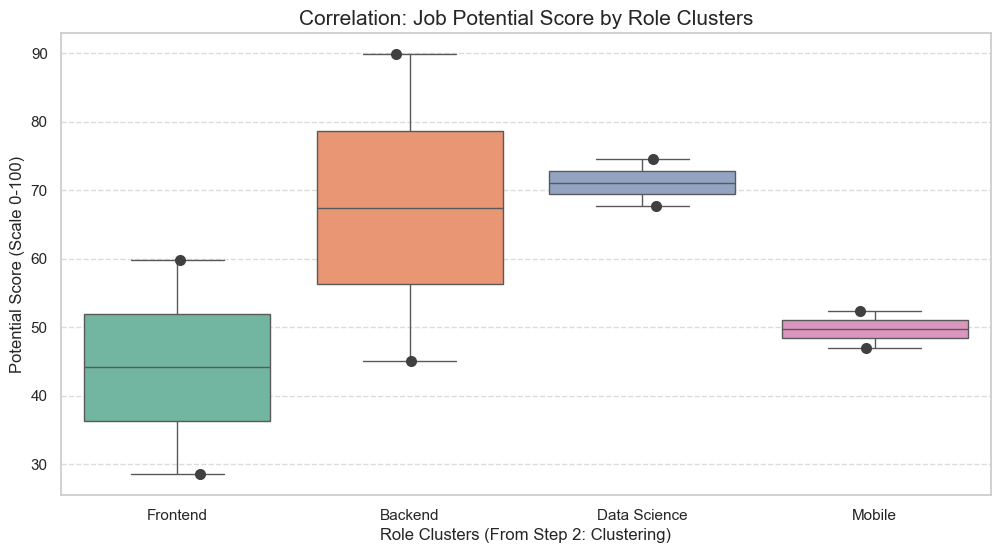


--- THỐNG KÊ TIÊM NĂNG TRUNG BÌNH THEO NHÓM ---
role_group
Data Science    71.127328
Backend         67.464575
Mobile          49.717611
Frontend        44.145951
Name: potential_score, dtype: float64


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- PHẦN HỖ TRỢ: Hàm chấm điểm Benefit (đã làm ở bước trước) ---
def transform_benefit_to_score(benefit_data):
    if not benefit_data or str(benefit_data) == 'nan': return 0
    text = str(benefit_data).lower()
    perks = {'13th salary': 2, 'insurance': 1.5, 'medical': 1.5, 'onsite': 3, 
             'salary review': 1, 'annual leave': 1, 'laptop': 1, 'training': 1}
    score = sum([v for k, v in perks.items() if k in text])
    return score

# 1. TẠO MOCK DATA MỞ RỘNG (Thêm cột role_group từ bước Clustering)
data_expanded = [
    # Cụm Frontend
    {'title': 'Senior React', 'level': 3, 'salary_max': 3500, 'experience_years_min': 5, 'benefits': ["13th salary", "Laptop"], 'role_group': 'Frontend'},
    {'title': 'Junior Vue', 'level': 1, 'salary_max': 1200, 'experience_years_min': 1, 'benefits': ["Insurance"], 'role_group': 'Frontend'},
    # Cụm Backend
    {'title': 'Java Lead', 'level': 4, 'salary_max': 5000, 'experience_years_min': 7, 'benefits': ["Onsite", "13th salary", "Medical"], 'role_group': 'Backend'},
    {'title': 'Python Dev', 'level': 2, 'salary_max': 2500, 'experience_years_min': 3, 'benefits': ["13th salary"], 'role_group': 'Backend'},
    # Cụm Data Science
    {'title': 'Data Scientist', 'level': 3, 'salary_max': 4000, 'experience_years_min': 4, 'benefits': ["13th salary", "Training"], 'role_group': 'Data Science'},
    {'title': 'AI Engineer', 'level': 2, 'salary_max': 3800, 'experience_years_min': 2, 'benefits': ["Laptop", "Onsite"], 'role_group': 'Data Science'},
    # Cụm Mobile
    {'title': 'iOS Developer', 'level': 2, 'salary_max': 2800, 'experience_years_min': 3, 'benefits': ["Insurance"], 'role_group': 'Mobile'},
    {'title': 'Android Senior', 'level': 3, 'salary_max': 3200, 'experience_years_min': 5, 'benefits': ["13th salary"], 'role_group': 'Mobile'}
]
mock_jobs = pd.DataFrame(data_expanded)

# 2. CHUYỂN ĐỔI VÀ TÍNH ĐIỂM POTENTIAL (Modeling)
mock_jobs['benefit_score'] = mock_jobs['benefits'].apply(transform_benefit_to_score)
mock_jobs['s_norm'] = mock_jobs['salary_max'] / mock_jobs['salary_max'].max()
mock_jobs['e_eff'] = mock_jobs['salary_max'] / (mock_jobs['experience_years_min'] + 1)
mock_jobs['e_norm'] = mock_jobs['e_eff'] / mock_jobs['e_eff'].max()
mock_jobs['b_norm'] = mock_jobs['benefit_score'] / mock_jobs['benefit_score'].max()
mock_jobs['l_norm'] = mock_jobs['level'] / 4

# Công thức Potential Score
mock_jobs['potential_score'] = (
    mock_jobs['s_norm'] * 0.45 + 
    mock_jobs['b_norm'] * 0.25 + 
    mock_jobs['e_norm'] * 0.20 + 
    mock_jobs['l_norm'] * 0.10
) * 100

# 3. VẼ BIỂU ĐỒ TƯƠNG QUAN POTENTIAL THEO CLUSTER
plt.figure(figsize=(12, 6))

# Sử dụng Boxplot để thấy sự phân bổ Potential trong từng Cluster
sns.boxplot(x='role_group', y='potential_score', data=mock_jobs, palette='Set2')
# Vẽ thêm các điểm dữ liệu đè lên boxplot để trực quan hơn
sns.stripplot(x='role_group', y='potential_score', data=mock_jobs, color=".25", size=8)

plt.title('Correlation: Job Potential Score by Role Clusters', fontsize=15)
plt.xlabel('Role Clusters (From Step 2: Clustering)', fontsize=12)
plt.ylabel('Potential Score (Scale 0-100)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Xuất bảng thống kê nhanh cho Slide
print("\n--- THỐNG KÊ TIÊM NĂNG TRUNG BÌNH THEO NHÓM ---")
print(mock_jobs.groupby('role_group')['potential_score'].mean().sort_values(ascending=False))

KHI ĐÃ CÓ DỮ LIỆU:

In [ ]:
def transform_benefit_to_score(benefit_data):
    # 1. Kiểm tra rỗng
    if not benefit_data or str(benefit_data).lower() == 'nan' or benefit_data == '[]':
        return 0
    
    # 2. Chuyển về chuỗi viết thường để tìm kiếm từ khóa
    text = str(benefit_data).lower()
    
    # 3. Từ điển đầy đủ nhất (Kết hợp các phiên bản trước)
    perks = {
        '13th salary': 2,        'insurance': 1.5,        'medical': 1.5,
        'onsite': 3,             'salary review': 1,      'annual leave': 1,
        'laptop': 1,             'monitor': 1,            'training': 1,
        'career path': 1,        'trip': 1,               'bonus': 1,
        'shui': 1,               'allowance': 1,
        'bonus': 1,              'healthcare': 1.5,       'travel': 1
    }
    
    score = 0
    # Tính điểm dựa trên từ khóa (Partial Match)
    for perk, value in perks.items():
        if perk in text:
            score += value
            
    # 4. Tính điểm thưởng cho độ đa dạng (Diversity Bonus)
    # Xử lý thông minh: Nếu là list thật thì dùng len(), nếu là string dạng list "['a', 'b']" thì đếm dấu phẩy
    try:
        if isinstance(benefit_data, list):
            score += len(benefit_data) * 0.2
        elif '[' in text and ']' in text:
            # Đếm số lượng phần tử trong chuỗi dạng list
            item_count = text.count(',') + 1
            score += item_count * 0.2
    except:
        pass
        
    return score

In [ ]:
# ==========================================
# STEP 1: POTENTIAL SCORE CALCULATION
# ==========================================

def transform_benefit_to_score(benefit_data):
    if not benefit_data or str(benefit_data).lower() == 'nan':
        return 0
    
    # Chuyển về chuỗi viết thường để tìm kiếm
    text = str(benefit_data).lower()
    
    # Từ điển các phúc lợi (Premium Perks)
    perks = {
        '13th salary': 2,        'insurance': 1.5,        'medical': 1.5,
        'onsite': 3,             'salary review': 1,      'annual leave': 1,
        'laptop': 1,             'monitor': 1,            'training': 1,
        'career path': 1,        'trip': 1,               'bonus': 1,
        'shui': 1,               'allowance': 1
    }
    
    score = 0
    for perk, value in perks.items():
        if perk in text:
            score += value
            
    # Thêm điểm cộng dựa trên độ đa dạng nếu dữ liệu là dạng list
    try:
        if '[' in str(benefit_data): # Nhận diện dạng list string
            items = str(benefit_data).count(',') + 1
            score += items * 0.2
    except:
        pass
    return score

# --- CHUẨN HÓA DỮ LIỆU TRƯỚC KHI TÍNH ---
# Đảm bảo các cột là dạng số
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')
df['experience_years_min'] = pd.to_numeric(df['experience_years_min'], errors='coerce').fillna(0)
df['level'] = pd.to_numeric(df['level'], errors='coerce').fillna(0)

# Xử lý lương Negotiable (null) - Điền bằng trung bình của nhóm vai trò hoặc trung bình chung
df['salary_max_filled'] = df.groupby('role_group')['salary_max'].transform(lambda x: x.fillna(x.median()))
df['salary_max_filled'] = df['salary_max_filled'].fillna(df['salary_max'].median())

# --- TÍNH TOÁN CÁC THÀNH PHẦN SCORE ---

# 1. Chấm điểm Benefit
df['benefit_score'] = df['benefits'].apply(transform_benefit_to_score)

# 2. Chuẩn hóa Salary (S) - 45%
max_sal = df['salary_max_filled'].max() if df['salary_max_filled'].max() > 0 else 1
df['s_norm'] = df['salary_max_filled'] / max_sal

# 3. Tính Experience Efficiency (E) - 20% (Lương cao / Năm kinh nghiệm)
df['e_eff'] = df['salary_max_filled'] / (df['experience_years_min'] + 1)
df['e_norm'] = df['e_eff'] / (df['e_eff'].max() if df['e_eff'].max() > 0 else 1)

# 4. Chuẩn hóa Benefit Score (B) - 25%
df['b_norm'] = df['benefit_score'] / (df['benefit_score'].max() if df['benefit_score'].max() > 0 else 1)

# 5. Chuẩn hóa Level (L) - 10% (Giả sử 0-4)
df['l_norm'] = df['level'] / 4

# --- CÔNG THỨC TỔNG HỢP POTENTIAL SCORE ---
df['potential_score'] = (
    df['s_norm'] * 0.45 + 
    df['b_norm'] * 0.25 + 
    df['e_norm'] * 0.20 + 
    df['l_norm'] * 0.10
) * 100

# Gán nhãn tiềm năng
def classify_potential(score):
    if score >= 70: return "High Potential (🔥)"
    if score >= 40: return "Medium Potential (⚡)"
    return "Low Potential (☁️)"

df['potential_label'] = df['potential_score'].apply(classify_potential)

print("--- LOG: TÍNH TOÁN ĐIỂM TIỀM NĂNG HOÀN TẤT ---")
print(f"Giá trị Potential trung bình: {df['potential_score'].mean():.2f}")
display(df[['title', 'role_group', 'salary_max', 'potential_score', 'potential_label']].head(10))

In [ ]:
# ==========================================
# STEP 2: STATISTICS & VISUALIZATION
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Thiết lập khổ biểu đồ
plt.figure(figsize=(14, 7))

# 2. Vẽ Boxplot tương quan giữa Nhóm vai trò và Điểm tiềm năng
# Sắp xếp các nhóm theo thứ tự điểm tiềm năng trung bình giảm dần
order = df.groupby('role_group')['potential_score'].mean().sort_values(ascending=False).index

sns.boxplot(x='role_group', y='potential_score', data=df, order=order, palette='viridis')

# Vẽ thêm Stripplot để thấy mật độ phân bố của 10k jobs
sns.stripplot(x='role_group', y='potential_score', data=df, order=order, 
              color=".3", size=2, alpha=0.3)

plt.title('Correlation: Job Potential Score by Role Clusters (Real Data)', fontsize=16)
plt.xlabel('Role Clusters (From Processing Step)', fontsize=12)
plt.ylabel('Potential Score (0-100)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. BẢNG THỐNG KÊ CHI TIẾT
print("\n--- THỐNG KÊ TIÊM NĂNG CHI TIẾT THEO NHÓM VAI TRÒ ---")
stat_df = df.groupby('role_group').agg({
    'potential_score': ['mean', 'std', 'count'],
    'salary_max': 'median',
    'benefit_score': 'mean'
}).round(2)

# Đổi tên cột cho rõ nghĩa
stat_df.columns = ['Avg Potential', 'Std Dev', 'Job Count', 'Median Salary', 'Avg Benefit Score']
display(stat_df.sort_values(by='Avg Potential', ascending=False))